# 🧬 Projet : Recommandation des Maladies-Gènes par Prédiction des Liens
## ✂️ Phase 4 — Préparation des Données Train / Test

---

### 🎯 Objectif de cette phase
Transformer le graphe en un **problème de classification binaire** :
- **Classe 1 (positif)** → paire (gène, maladie) avec un lien réel ✅
- **Classe 0 (négatif)** → paire (gène, maladie) sans lien connu ❌

---

### 📖 Schéma de la Phase 4

```
GRAPHE COMPLET (15,000+ arêtes)
         │
         ▼
┌─────────────────────────────────┐
│   EXEMPLES POSITIFS (arêtes)   │
│   80% → TRAIN positifs         │
│   20% → TEST  positifs (cachés)│
└─────────────────────────────────┘
         +
┌─────────────────────────────────┐
│   EXEMPLES NÉGATIFS (non-liens)│
│   80% → TRAIN négatifs         │
│   20% → TEST  négatifs         │
└─────────────────────────────────┘
         │
         ▼
   GRAPHE D'ENTRAÎNEMENT
   (sans les 20% d'arêtes test)
         │
         ▼
   FEATURES (Phase 5)
   → Algorithmes d'IA (Phase 6)
```

## ⚙️ Cellule 1 — Importation des bibliothèques

In [1]:
import os
import pickle
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from networkx.algorithms import bipartite
import warnings

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print('✅ Bibliothèques importées avec succès !')

✅ Bibliothèques importées avec succès !


## 📁 Cellule 2 — Chargement du graphe (Phase 3)

In [2]:
BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..'))
GRAPH_DIR = os.path.join(BASE_DIR, 'data', 'graph')
SPLIT_DIR = os.path.join(BASE_DIR, 'data', 'splits')
FIG_DIR   = os.path.join(BASE_DIR, 'results', 'figures')

os.makedirs(SPLIT_DIR, exist_ok=True)
os.makedirs(FIG_DIR,   exist_ok=True)

# ── Charger le graphe sauvegardé en Phase 3
pickle_path = os.path.join(GRAPH_DIR, 'gene_disease_graph.pkl')
with open(pickle_path, 'rb') as f:
    G = pickle.load(f)

# ── Récupérer les listes de nœuds par type
gene_nodes    = [n for n in G.nodes() if G.nodes[n].get('node_type') == 'gene']
disease_nodes = [n for n in G.nodes() if G.nodes[n].get('node_type') == 'disease']
all_edges     = list(G.edges())

print('✅ Graphe chargé !')
print(f'   🧬 Nœuds gènes     : {len(gene_nodes):,}')
print(f'   🦠 Nœuds maladies  : {len(disease_nodes):,}')
print(f'   🔗 Arêtes totales  : {len(all_edges):,}')

✅ Graphe chargé !
   🧬 Nœuds gènes     : 5,529
   🦠 Nœuds maladies  : 11,026
   🔗 Arêtes totales  : 15,940


## ✅ Cellule 3 — Génération des Exemples POSITIFS

> Les exemples positifs = les arêtes existantes dans le graphe
> On les mélange aléatoirement puis on les coupe en 80% / 20%

In [3]:
# ── Mélanger les arêtes aléatoirement
edges_shuffled = all_edges.copy()
random.shuffle(edges_shuffled)

# ── Calcul des tailles
TEST_RATIO = 0.20   # 20% pour le test
n_total    = len(edges_shuffled)
n_test     = int(n_total * TEST_RATIO)
n_train    = n_total - n_test

# ── Division train / test
pos_test  = edges_shuffled[:n_test]
pos_train = edges_shuffled[n_test:]

print('╔══════════════════════════════════════════════════╗')
print('║        ✅ EXEMPLES POSITIFS (arêtes réelles)     ║')
print('╠══════════════════════════════════════════════════╣')
print(f'║  Total arêtes           : {n_total:>6,}               ║')
print(f'║  Train (80%)            : {n_train:>6,}               ║')
print(f'║  Test  (20%)            : {n_test:>6,}               ║')
print('╠══════════════════════════════════════════════════╣')
print(f'║  Exemples TRAIN positifs: {len(pos_train):>6,}               ║')
print(f'║  Exemples TEST  positifs: {len(pos_test):>6,}               ║')
print('╚══════════════════════════════════════════════════╝')

print(f'\n📋 Aperçu de quelques arêtes train positives :')
for e in pos_train[:5]:
    print(f'   ✅ {e[0]}  ──►  {e[1]}')
print(f'   ...')
print(f'\n📋 Aperçu de quelques arêtes TEST positives (cachées) :')
for e in pos_test[:5]:
    print(f'   ✅ {e[0]}  ──►  {e[1]}')

╔══════════════════════════════════════════════════╗
║        ✅ EXEMPLES POSITIFS (arêtes réelles)     ║
╠══════════════════════════════════════════════════╣
║  Total arêtes           : 15,940               ║
║  Train (80%)            : 12,752               ║
║  Test  (20%)            :  3,188               ║
╠══════════════════════════════════════════════════╣
║  Exemples TRAIN positifs: 12,752               ║
║  Exemples TEST  positifs:  3,188               ║
╚══════════════════════════════════════════════════╝

📋 Aperçu de quelques arêtes train positives :
   ✅ G_2694  ──►  D_ORPHA:332
   ✅ G_64072  ──►  D_ORPHA:90636
   ✅ G_6716  ──►  D_ORPHA:1331
   ✅ G_859  ──►  D_ORPHA:101016
   ✅ G_7248  ──►  D_ORPHA:805
   ...

📋 Aperçu de quelques arêtes TEST positives (cachées) :
   ✅ G_7287  ──►  D_ORPHA:791
   ✅ G_653509  ──►  D_OMIM:619611
   ✅ G_6496  ──►  D_ORPHA:220386
   ✅ G_55384  ──►  D_ORPHA:254531
   ✅ G_27063  ──►  D_ORPHA:154


## ❌ Cellule 4 — Génération des Exemples NÉGATIFS

> Les exemples négatifs = paires (gène, maladie) qui N'ONT PAS de lien dans le graphe
>
> ⚠️ **Stratégie :** on tire aléatoirement des paires gène-maladie
> et on vérifie qu'elles n'existent pas dans le graphe

In [4]:
# ── Créer un ensemble rapide des arêtes existantes pour vérification O(1)
existing_edges_set = set()
for u, v in G.edges():
    existing_edges_set.add((u, v))
    existing_edges_set.add((v, u))   # graphe non-orienté

print(f'⏳ Génération de {n_total:,} exemples négatifs...')

negative_samples = []
max_attempts     = n_total * 20    # sécurité pour éviter boucle infinie
attempts         = 0

while len(negative_samples) < n_total and attempts < max_attempts:
    # Tirer un gène et une maladie au hasard
    gene    = random.choice(gene_nodes)
    disease = random.choice(disease_nodes)

    # Vérifier que la paire n'existe pas déjà
    if (gene, disease) not in existing_edges_set:
        negative_samples.append((gene, disease))
        existing_edges_set.add((gene, disease))  # éviter doublons

    attempts += 1

# ── Division train / test des négatifs
random.shuffle(negative_samples)
neg_test  = negative_samples[:n_test]
neg_train = negative_samples[n_test:n_total]

print(f'✅ Génération terminée !')
print(f'   Tentatives effectuées  : {attempts:,}')
print(f'   Négatifs générés       : {len(negative_samples):,}')
print(f'   Négatifs TRAIN         : {len(neg_train):,}')
print(f'   Négatifs TEST          : {len(neg_test):,}')

print(f'\n📋 Aperçu de quelques exemples négatifs train :')
for e in neg_train[:5]:
    print(f'   ❌ {e[0]}  ──✗──  {e[1]}')

⏳ Génération de 15,940 exemples négatifs...
✅ Génération terminée !
   Tentatives effectuées  : 15,944
   Négatifs générés       : 15,940
   Négatifs TRAIN         : 12,752
   Négatifs TEST          : 3,188

📋 Aperçu de quelques exemples négatifs train :
   ❌ G_51106  ──✗──  D_ORPHA:276238
   ❌ G_779  ──✗──  D_OMIM:261990
   ❌ G_10112  ──✗──  D_ORPHA:140917
   ❌ G_57731  ──✗──  D_OMIM:614653
   ❌ G_144245  ──✗──  D_ORPHA:98954


## 🏗️ Cellule 5 — Construction du Graphe d'ENTRAÎNEMENT

> Le graphe d'entraînement = graphe original SANS les arêtes de test
>
> C'est ce graphe que les algorithmes d'IA vont utiliser pour apprendre

In [5]:
# ── Créer le graphe d'entraînement en retirant les arêtes de test
G_train = G.copy()
G_train.remove_edges_from(pos_test)

# ── Vérifications
n_comp_original = nx.number_connected_components(G)
n_comp_train    = nx.number_connected_components(G_train)

print('╔═════════════════════════════════════════════════════╗')
print('║      🏗️  GRAPHE D\'ENTRAÎNEMENT CONSTRUIT           ║')
print('╠═════════════════════════════════════════════════════╣')
print(f'║  Arêtes graphe original   : {G.number_of_edges():>7,}            ║')
print(f'║  Arêtes test retirées     : {len(pos_test):>7,}            ║')
print(f'║  Arêtes graphe train      : {G_train.number_of_edges():>7,}            ║')
print('╠═════════════════════════════════════════════════════╣')
print(f'║  Composantes original     : {n_comp_original:>7,}            ║')
print(f'║  Composantes train        : {n_comp_train:>7,}            ║')
print('╚═════════════════════════════════════════════════════╝')

# ── Analyse de l'impact du retrait
diff_comp = n_comp_train - n_comp_original
print()
if diff_comp == 0:
    print('✅ La structure du graphe est PRÉSERVÉE')
    print('   Le retrait des 20% d\'arêtes n\'a pas fragmenté le graphe')
else:
    print(f'⚠️  Le retrait a créé {diff_comp} nouvelles composantes')
    print('   C\'est normal pour un graphe creux, les algorithmes le gèrent')

╔═════════════════════════════════════════════════════╗
║      🏗️  GRAPHE D'ENTRAÎNEMENT CONSTRUIT           ║
╠═════════════════════════════════════════════════════╣
║  Arêtes graphe original   :  15,940            ║
║  Arêtes test retirées     :   3,188            ║
║  Arêtes graphe train      :  12,752            ║
╠═════════════════════════════════════════════════════╣
║  Composantes original     :   2,381            ║
║  Composantes train        :   4,885            ║
╚═════════════════════════════════════════════════════╝

⚠️  Le retrait a créé 2504 nouvelles composantes
   C'est normal pour un graphe creux, les algorithmes le gèrent


## 📦 Cellule 6 — Assemblage des jeux de données finaux

> On crée 2 DataFrames avec labels :
> - **label = 1** → lien réel (positif)
> - **label = 0** → pas de lien (négatif)

In [6]:
# ── Construire le DataFrame TRAIN
train_pos_df = pd.DataFrame(pos_train,  columns=['node1','node2'])
train_pos_df['label'] = 1

train_neg_df = pd.DataFrame(neg_train,  columns=['node1','node2'])
train_neg_df['label'] = 0

df_train = pd.concat([train_pos_df, train_neg_df], ignore_index=True)
df_train  = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

# ── Construire le DataFrame TEST
test_pos_df = pd.DataFrame(pos_test,  columns=['node1','node2'])
test_pos_df['label'] = 1

test_neg_df = pd.DataFrame(neg_test,  columns=['node1','node2'])
test_neg_df['label'] = 0

df_test = pd.concat([test_pos_df, test_neg_df], ignore_index=True)
df_test  = df_test.sample(frac=1, random_state=42).reset_index(drop=True)

# ── Affichage
print('╔═══════════════════════════════════════════════════╗')
print('║          📦 JEUX DE DONNÉES ASSEMBLÉS             ║')
print('╠═══════════════════════════════════════════════════╣')
print(f'║  TRAIN total     : {len(df_train):>7,} exemples             ║')
print(f'║    Positifs (1)  : {(df_train.label==1).sum():>7,}               ║')
print(f'║    Négatifs (0)  : {(df_train.label==0).sum():>7,}               ║')
print('╠═══════════════════════════════════════════════════╣')
print(f'║  TEST total      : {len(df_test):>7,} exemples             ║')
print(f'║    Positifs (1)  : {(df_test.label==1).sum():>7,}               ║')
print(f'║    Négatifs (0)  : {(df_test.label==0).sum():>7,}               ║')
print('╚═══════════════════════════════════════════════════╝')

print(f'\n📋 Aperçu du DataFrame TRAIN (mélangé) :')
df_train.head(10)

╔═══════════════════════════════════════════════════╗
║          📦 JEUX DE DONNÉES ASSEMBLÉS             ║
╠═══════════════════════════════════════════════════╣
║  TRAIN total     :  25,504 exemples             ║
║    Positifs (1)  :  12,752               ║
║    Négatifs (0)  :  12,752               ║
╠═══════════════════════════════════════════════════╣
║  TEST total      :   6,376 exemples             ║
║    Positifs (1)  :   3,188               ║
║    Négatifs (0)  :   3,188               ║
╚═══════════════════════════════════════════════════╝

📋 Aperçu du DataFrame TRAIN (mélangé) :


,node1,node2,label
0,G_22827,D_ORPHA:404499,0
1,G_473,D_OMIM:616975,1
2,G_120892,D_ORPHA:2828,1
3,G_3630,D_OMIM:618858,1
4,G_57654,D_OMIM:621214,0
5,G_10568,D_OMIM:613686,0
6,G_90416,D_ORPHA:48818,0
7,G_2189,D_ORPHA:84,1
8,G_50511,D_OMIM:270960,1
9,G_6857,D_OMIM:614700,0


## 📊 Cellule 7 — Visualisation de l'équilibre des classes

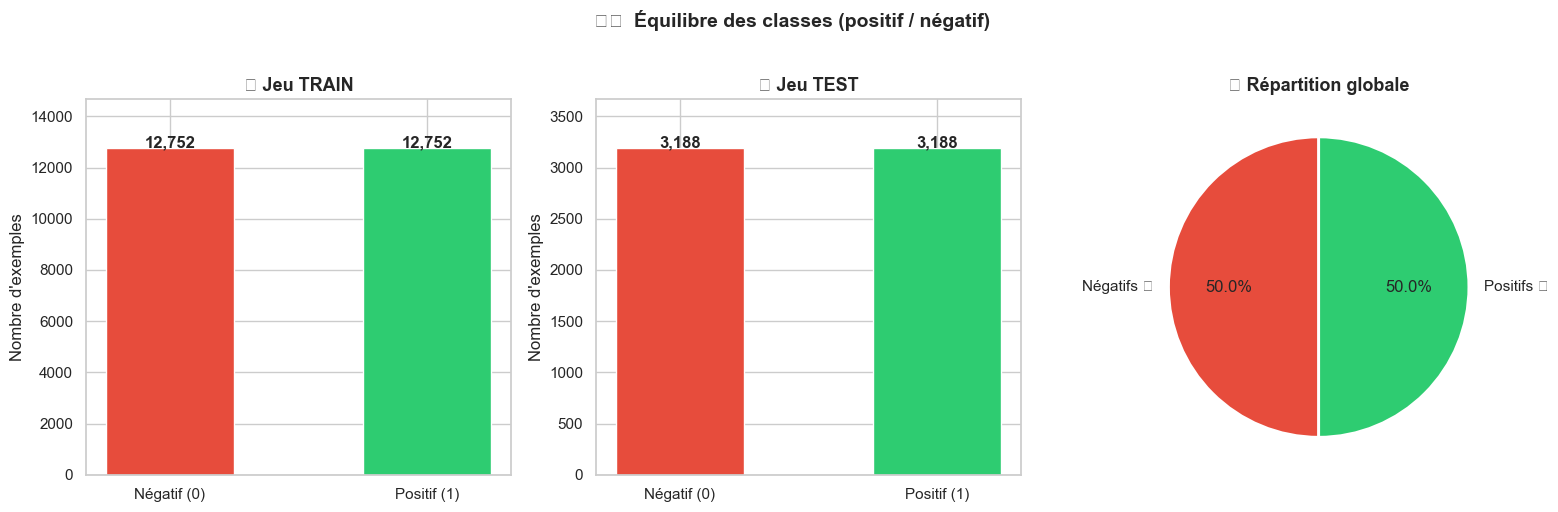

⚖️  Ratio positifs/total dans TRAIN : 0.500
   → Un ratio de 0.5 signifie jeu de données parfaitement équilibré ✅


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 1. Répartition TRAIN
train_counts = df_train['label'].value_counts().sort_index()
colors = ['#E74C3C', '#2ECC71']
bars = axes[0].bar(['Négatif (0)','Positif (1)'],
                   train_counts.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, train_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('📚 Jeu TRAIN', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Nombre d\'exemples')
axes[0].set_ylim(0, max(train_counts.values)*1.15)

# ── 2. Répartition TEST
test_counts = df_test['label'].value_counts().sort_index()
bars = axes[1].bar(['Négatif (0)','Positif (1)'],
                   test_counts.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, test_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:,}', ha='center', fontweight='bold')
axes[1].set_title('🧪 Jeu TEST', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Nombre d\'exemples')
axes[1].set_ylim(0, max(test_counts.values)*1.15)

# ── 3. Vue globale en pie chart
total_pos = len(df_train[df_train.label==1]) + len(df_test[df_test.label==1])
total_neg = len(df_train[df_train.label==0]) + len(df_test[df_test.label==0])
axes[2].pie([total_neg, total_pos],
            labels=['Négatifs ❌', 'Positifs ✅'],
            autopct='%1.1f%%', colors=colors,
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[2].set_title('🌍 Répartition globale', fontweight='bold', fontsize=13)

plt.suptitle('⚖️  Équilibre des classes (positif / négatif)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_balance.png'), dpi=150, bbox_inches='tight')
plt.show()

ratio_train = (df_train.label==1).mean()
print(f'⚖️  Ratio positifs/total dans TRAIN : {ratio_train:.3f}')
print(f'   → Un ratio de 0.5 signifie jeu de données parfaitement équilibré ✅')

## 🔍 Cellule 8 — Vérification de la qualité des données

In [8]:
print('🔍 VÉRIFICATIONS DE QUALITÉ')
print('═' * 50)

# ── Test 1 : Pas de fuite entre train et test
train_set = set(map(tuple, df_train[['node1','node2']].values))
test_set  = set(map(tuple, df_test[['node1','node2']].values))
overlap   = train_set & test_set
test1 = len(overlap) == 0
print(f'  ✅ Test 1 - Pas de fuite train/test    : {test1} (overlap={len(overlap)})')

# ── Test 2 : Les positifs train sont bien dans le graphe d'entraînement
train_pos_pairs = [(r.node1, r.node2) for r in df_train[df_train.label==1].itertuples()]
in_graph = sum(1 for u, v in train_pos_pairs if G_train.has_edge(u,v) or G_train.has_edge(v,u))
test2 = in_graph == len(train_pos_pairs)
print(f'  ✅ Test 2 - Positifs train dans G_train : {test2} ({in_graph}/{len(train_pos_pairs)})')

# ── Test 3 : Les positifs test NE SONT PAS dans le graphe d'entraînement
test_pos_pairs = [(r.node1, r.node2) for r in df_test[df_test.label==1].itertuples()]
not_in = sum(1 for u, v in test_pos_pairs if not G_train.has_edge(u,v) and not G_train.has_edge(v,u))
test3 = not_in == len(test_pos_pairs)
print(f'  ✅ Test 3 - Positifs test absents de G_train : {test3} ({not_in}/{len(test_pos_pairs)})')

# ── Test 4 : Les négatifs ne sont pas dans le graphe original
neg_pairs = [(r.node1, r.node2) for r in df_train[df_train.label==0].head(1000).itertuples()]
not_real  = sum(1 for u, v in neg_pairs if not G.has_edge(u,v) and not G.has_edge(v,u))
test4 = not_real == len(neg_pairs)
print(f'  ✅ Test 4 - Négatifs absents du graphe : {test4} ({not_real}/1000 vérifiés)')

# ── Test 5 : Équilibre des classes
ratio = (df_train.label == 1).mean()
test5 = 0.45 <= ratio <= 0.55
print(f'  ✅ Test 5 - Classes équilibrées       : {test5} (ratio={ratio:.3f})')

print('═' * 50)
all_ok = all([test1, test2, test3, test4, test5])
if all_ok:
    print('\n🎉 TOUS LES TESTS PASSENT — Données prêtes pour la Phase 5 !')
else:
    print('\n⚠️  Certains tests échouent — vérifier la préparation')

🔍 VÉRIFICATIONS DE QUALITÉ
══════════════════════════════════════════════════
  ✅ Test 1 - Pas de fuite train/test    : True (overlap=0)
  ✅ Test 2 - Positifs train dans G_train : True (12752/12752)
  ✅ Test 3 - Positifs test absents de G_train : True (3188/3188)
  ✅ Test 4 - Négatifs absents du graphe : True (1000/1000 vérifiés)
  ✅ Test 5 - Classes équilibrées       : True (ratio=0.500)
══════════════════════════════════════════════════

🎉 TOUS LES TESTS PASSENT — Données prêtes pour la Phase 5 !


## 📊 Cellule 9 — Analyse de la couverture des nœuds

In [9]:
# ── Quels gènes/maladies apparaissent dans train et test ?
train_genes    = set(df_train[df_train.label==1]['node1'].tolist() +
                     df_train[df_train.label==1]['node2'].tolist())
train_genes    = {n for n in train_genes if 'G_' in n}

test_genes     = set(df_test[df_test.label==1]['node1'].tolist() +
                     df_test[df_test.label==1]['node2'].tolist())
test_genes     = {n for n in test_genes if 'G_' in n}

train_diseases = set(df_train[df_train.label==1]['node1'].tolist() +
                     df_train[df_train.label==1]['node2'].tolist())
train_diseases = {n for n in train_diseases if 'D_' in n}

test_diseases  = set(df_test[df_test.label==1]['node1'].tolist() +
                     df_test[df_test.label==1]['node2'].tolist())
test_diseases  = {n for n in test_diseases if 'D_' in n}

genes_in_both     = train_genes & test_genes
diseases_in_both  = train_diseases & test_diseases
genes_only_test   = test_genes - train_genes
diseases_only_test= test_diseases - train_diseases

print('📊 COUVERTURE DES NŒUDS')
print('═' * 52)
print(f'  Gènes dans TRAIN          : {len(train_genes):,}')
print(f'  Gènes dans TEST           : {len(test_genes):,}')
print(f'  Gènes dans TRAIN et TEST  : {len(genes_in_both):,}')
print(f'  Gènes SEULEMENT dans TEST : {len(genes_only_test):,}')
print()
print(f'  Maladies dans TRAIN           : {len(train_diseases):,}')
print(f'  Maladies dans TEST            : {len(test_diseases):,}')
print(f'  Maladies dans TRAIN et TEST   : {len(diseases_in_both):,}')
print(f'  Maladies SEULEMENT dans TEST  : {len(diseases_only_test):,}')
print('═' * 52)
print()
print('💡 Interprétation :')
if len(genes_only_test) == 0:
    print('   → Tous les gènes du test sont aussi dans le train ✅')
    print('   → Le modèle connaîtra tous les nœuds du test')
else:
    print(f'   → {len(genes_only_test)} gènes sont uniquement dans le test')
    print('   → Ces nœuds seront difficiles à prédire (cold start problem)')

📊 COUVERTURE DES NŒUDS
════════════════════════════════════════════════════
  Gènes dans TRAIN          : 5,200
  Gènes dans TEST           : 2,344
  Gènes dans TRAIN et TEST  : 2,015
  Gènes SEULEMENT dans TEST : 329

  Maladies dans TRAIN           : 9,033
  Maladies dans TEST            : 2,667
  Maladies dans TRAIN et TEST   : 674
  Maladies SEULEMENT dans TEST  : 1,993
════════════════════════════════════════════════════

💡 Interprétation :
   → 329 gènes sont uniquement dans le test
   → Ces nœuds seront difficiles à prédire (cold start problem)


## 🎨 Cellule 10 — Visualisation des arêtes train vs test sur le graphe

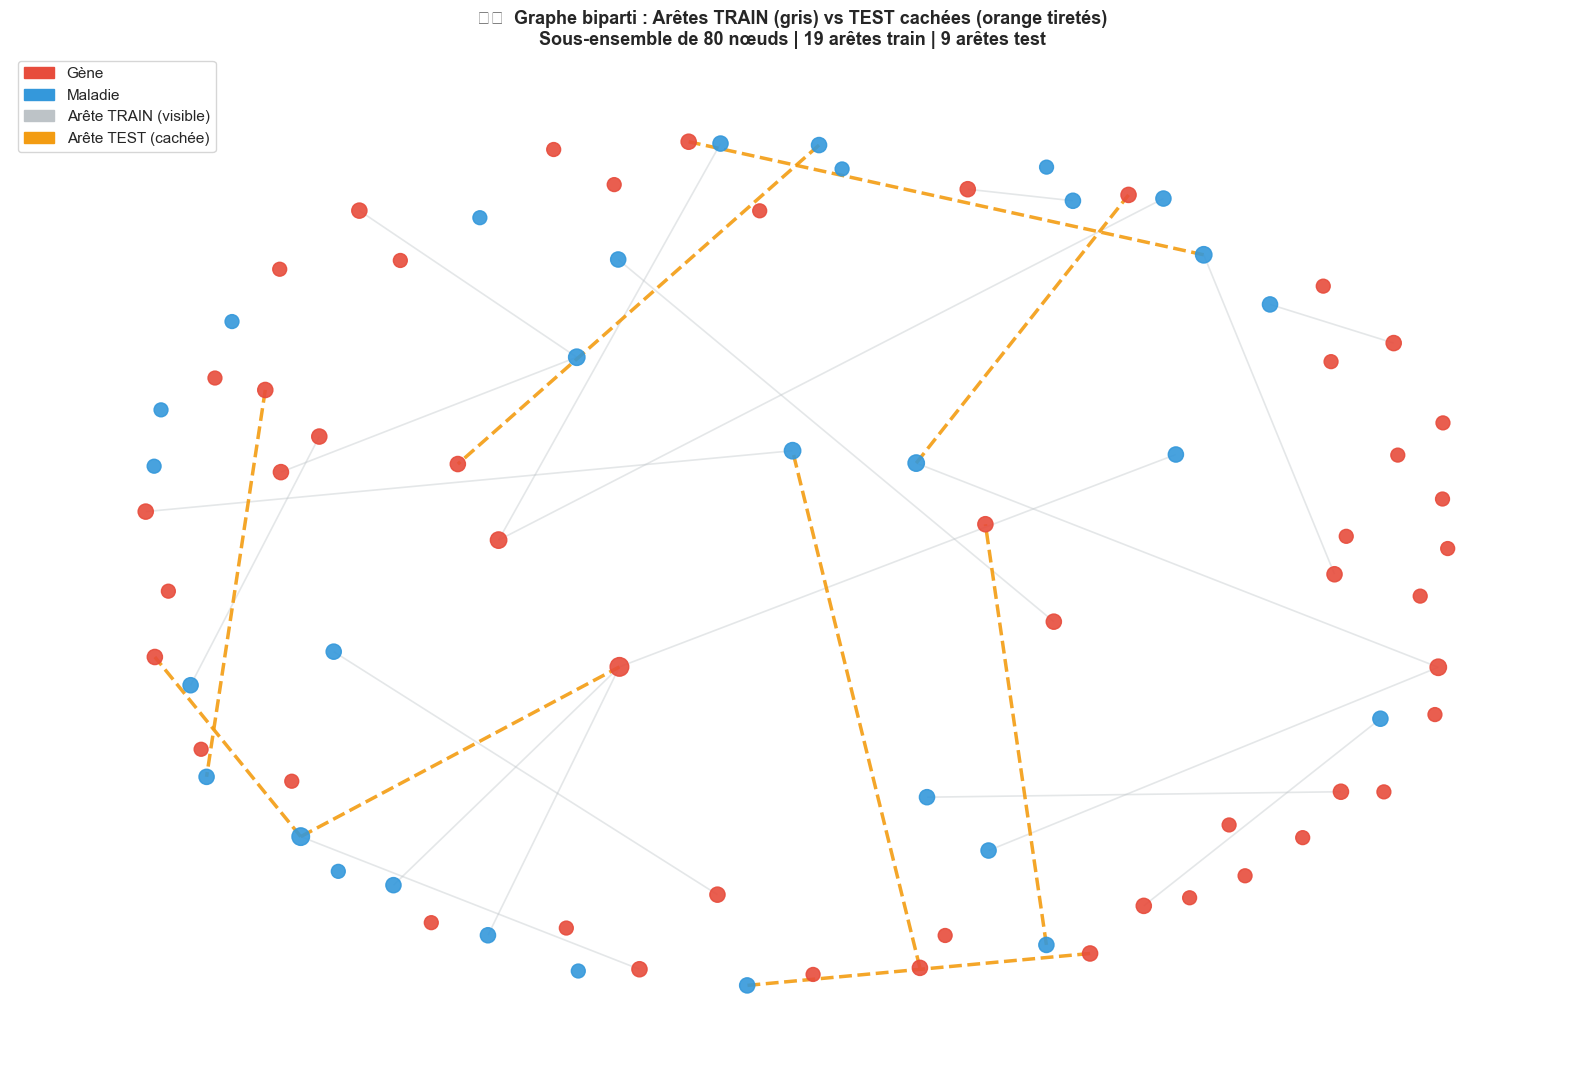

💾 Figure sauvegardée dans results/figures/


In [10]:
# ── Sous-graphe de 80 nœuds pour visualisation
top_nodes = [n for n, _ in sorted(G.degree, key=lambda x: x[1], reverse=True)[:40]]
neighbors = []
for n in top_nodes:
    neighbors.extend(list(G.neighbors(n))[:3])
viz_nodes = list(set(top_nodes + neighbors))[:80]
G_viz     = G.subgraph(viz_nodes).copy()

# ── Identifier les arêtes train vs test dans ce sous-graphe
pos_test_set  = set(map(tuple, [(u,v) for u,v in pos_test]))
pos_test_set |= set(map(tuple, [(v,u) for u,v in pos_test]))

edges_train_viz = [(u,v) for u,v in G_viz.edges() if (u,v) not in pos_test_set]
edges_test_viz  = [(u,v) for u,v in G_viz.edges() if (u,v) in pos_test_set]

fig, ax = plt.subplots(figsize=(16, 11))
pos = nx.spring_layout(G_viz, seed=42, k=0.9)

node_colors = ['#E74C3C' if G_viz.nodes[n].get('node_type')=='gene'
               else '#3498DB' for n in G_viz.nodes()]
node_sizes  = [100 + G_viz.degree(n)*20 for n in G_viz.nodes()]

# Arêtes train = gris
nx.draw_networkx_edges(G_viz, pos, edgelist=edges_train_viz,
                       edge_color='#BDC3C7', alpha=0.4, width=1.2, ax=ax)
# Arêtes test = orange vif
nx.draw_networkx_edges(G_viz, pos, edgelist=edges_test_viz,
                       edge_color='#F39C12', alpha=0.9, width=2.5,
                       style='dashed', ax=ax)
nx.draw_networkx_nodes(G_viz, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9, ax=ax)

patch_gene    = mpatches.Patch(color='#E74C3C',  label='Gène')
patch_disease = mpatches.Patch(color='#3498DB',  label='Maladie')
patch_train   = mpatches.Patch(color='#BDC3C7',  label='Arête TRAIN (visible)')
patch_test    = mpatches.Patch(color='#F39C12',  label='Arête TEST (cachée)')
ax.legend(handles=[patch_gene, patch_disease, patch_train, patch_test],
          fontsize=11, loc='upper left')
ax.set_title('✂️  Graphe biparti : Arêtes TRAIN (gris) vs TEST cachées (orange tiretés)\n'
             f'Sous-ensemble de {len(G_viz.nodes())} nœuds | '
             f'{len(edges_train_viz)} arêtes train | {len(edges_test_viz)} arêtes test',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'train_test_split_viz.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure sauvegardée dans results/figures/')

## 💾 Cellule 11 — Sauvegarde de tous les fichiers

In [11]:
# ── DataFrames train et test
train_path = os.path.join(SPLIT_DIR, 'train_data.csv')
test_path  = os.path.join(SPLIT_DIR, 'test_data.csv')
df_train.to_csv(train_path, index=False)
df_test.to_csv(test_path,  index=False)

# ── Graphe d'entraînement
g_train_path = os.path.join(SPLIT_DIR, 'G_train.pkl')
with open(g_train_path, 'wb') as f:
    pickle.dump(G_train, f)

# ── Listes des arêtes positives/négatives (pour les phases suivantes)
pd.DataFrame(pos_train, columns=['node1','node2']).to_csv(
    os.path.join(SPLIT_DIR, 'pos_train_edges.csv'), index=False)
pd.DataFrame(pos_test,  columns=['node1','node2']).to_csv(
    os.path.join(SPLIT_DIR, 'pos_test_edges.csv'),  index=False)
pd.DataFrame(neg_train, columns=['node1','node2']).to_csv(
    os.path.join(SPLIT_DIR, 'neg_train_edges.csv'), index=False)
pd.DataFrame(neg_test,  columns=['node1','node2']).to_csv(
    os.path.join(SPLIT_DIR, 'neg_test_edges.csv'),  index=False)

print('💾 Tous les fichiers sauvegardés dans data/splits/ :')
print()
for fname in sorted(os.listdir(SPLIT_DIR)):
    fpath = os.path.join(SPLIT_DIR, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f'   ✅ {fname:<30} ({size:.1f} KB)')

💾 Tous les fichiers sauvegardés dans data/splits/ :

   ✅ G_train.pkl                    (928.5 KB)
   ✅ neg_test_edges.csv             (70.2 KB)
   ✅ neg_train_edges.csv            (281.2 KB)
   ✅ pos_test_edges.csv             (69.4 KB)
   ✅ pos_train_edges.csv            (278.1 KB)
   ✅ test_data.csv                  (152.1 KB)
   ✅ train_data.csv                 (609.1 KB)


## ✅ Cellule 12 — Résumé final de la Phase 4

In [17]:
print('╔════════════════════════════════════════════════════════╗')
print('║        ✅ PHASE 4 TERMINÉE AVEC SUCCÈS !               ║')
print('╠════════════════════════════════════════════════════════╣')
print(f'║  📚 TRAIN   : {len(df_train):>6,} exemples                          ║')
print(f'║     Positifs: {(df_train.label==1).sum():>6,}  Négatifs: {(df_train.label==0).sum():>6,}                 ║')
print(f'║  🧪 TEST    : {len(df_test):>6,} exemples                          ║')
print(f'║     Positifs: {(df_test.label==1).sum():>6,}  Négatifs: {(df_test.label==0).sum():>6,}                 ║')
print('╠════════════════════════════════════════════════════════╣')
print('║  ✅ Vérifications de qualité : TOUTES PASSÉES          ║')
print('║  💾 Fichiers sauvegardés dans data/splits/             ║')
print('╠════════════════════════════════════════════════════════╣')
print('║  ➡️  Prochaine étape : Phase 5                         ║')
print('║     Méthodes baseline (Common Neighbors, Jaccard...)   ║')
print('╚════════════════════════════════════════════════════════╝')

╔════════════════════════════════════════════════════════╗
║        ✅ PHASE 4 TERMINÉE AVEC SUCCÈS !               ║
╠════════════════════════════════════════════════════════╣
║  📚 TRAIN   : 25,504 exemples                          ║
║     Positifs: 12,752  Négatifs: 12,752                 ║
║  🧪 TEST    :  6,376 exemples                          ║
║     Positifs:  3,188  Négatifs:  3,188                 ║
╠════════════════════════════════════════════════════════╣
║  ✅ Vérifications de qualité : TOUTES PASSÉES          ║
║  💾 Fichiers sauvegardés dans data/splits/             ║
╠════════════════════════════════════════════════════════╣
║  ➡️  Prochaine étape : Phase 5                         ║
║     Méthodes baseline (Common Neighbors, Jaccard...)   ║
╚════════════════════════════════════════════════════════╝
